In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/vincenzorrei/EDU-Datasets/refs/heads/main/QualityOfLife.csv')


In [13]:
df.head()

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,...,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category,Value Enc,Property P
0,Afghanistan,32.15,'Very Low',25.33,'Low',24.24,'Low',0.00,NaN,21.08,...,7.8,'Low',56.17,'Very High',84.44,'Very High',0.0,NaN,0.00,7.80
1,Aland Islands,125.01,'Very High',71.81,'High',79.72,'High',0.00,NaN,53.44,...,5.33,'Low',19.05,'Very Low',18.05,'Very Low',0.0,NaN,0.00,5.33
2,Albania,42.82,'Low',55.52,'Moderate',48.21,'Moderate',86.43,'Very High',40.85,...,14.88,'High',36.74,'Moderate',77.25,'High',NaN,'Low',104.16,14.88
3,Alderney,0.00,NaN,83.79,'Very High',100.00,'Very High',0.00,NaN,0.00,...,0.0,NaN,5.00,'Very Low',1.72,'Very Low',0.0,NaN,0.00,0.00
4,Algeria,27.60,'Very Low',47.54,'Moderate',54.43,'Moderate',94.82,'Very High',25.31,...,21.7,'Very High',45.09,'High',63.87,'High',NaN,'Very Low',98.83,21.70


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            236 non-null    object 
 1   Purchasing Power Value             236 non-null    float64
 2   Purchasing Power Category          190 non-null    object 
 3   Safety Value                       236 non-null    float64
 4   Safety Category                    234 non-null    object 
 5   Health Care Value                  236 non-null    float64
 6   Health Care Category               221 non-null    object 
 7   Climate Value                      236 non-null    float64
 8   Climate Category                   114 non-null    object 
 9   Cost of Living Value               236 non-null    float64
 10  Cost of Living Category            191 non-null    object 
 11  Property Price to Income Value     236 non-null    object 

In [5]:
# Remove ': ' prefix and convert to numeric
df['Value Enc'] = df['Quality of Life Value'].str.replace(': ', '', regex=False)


In [6]:
df['Value Enc'] = df['Value Enc'].str.strip("'")


In [7]:
# convert to numeric, coercing errors to NaN
df["Quality of Life Value"] = pd.to_numeric(df["Quality of Life Value"], errors='coerce')

# Check for problematic observations
print(df['Value Enc'].isna().sum(), "NaN values found in 'Value Enc' column.")

0 NaN values found in 'Value Enc' column.


In [8]:
df["Value Enc"] = pd.to_numeric(df["Value Enc"], errors='coerce')

In [10]:
df["Property P"] = df["Property Price to Income Value"].str.replace(': ', '', regex=False)
df["Property P"] = df["Property Price to Income Value"].str.strip("'")
df["Property P"] = df["Property P"].str.replace(',', '', regex=False)


In [11]:
df["Property P"] = pd.to_numeric(df["Property P"], errors='coerce')
df["Property P"].isna().sum(), "NaN values found in 'Property P' column."


(np.int64(0), "NaN values found in 'Property P' column.")

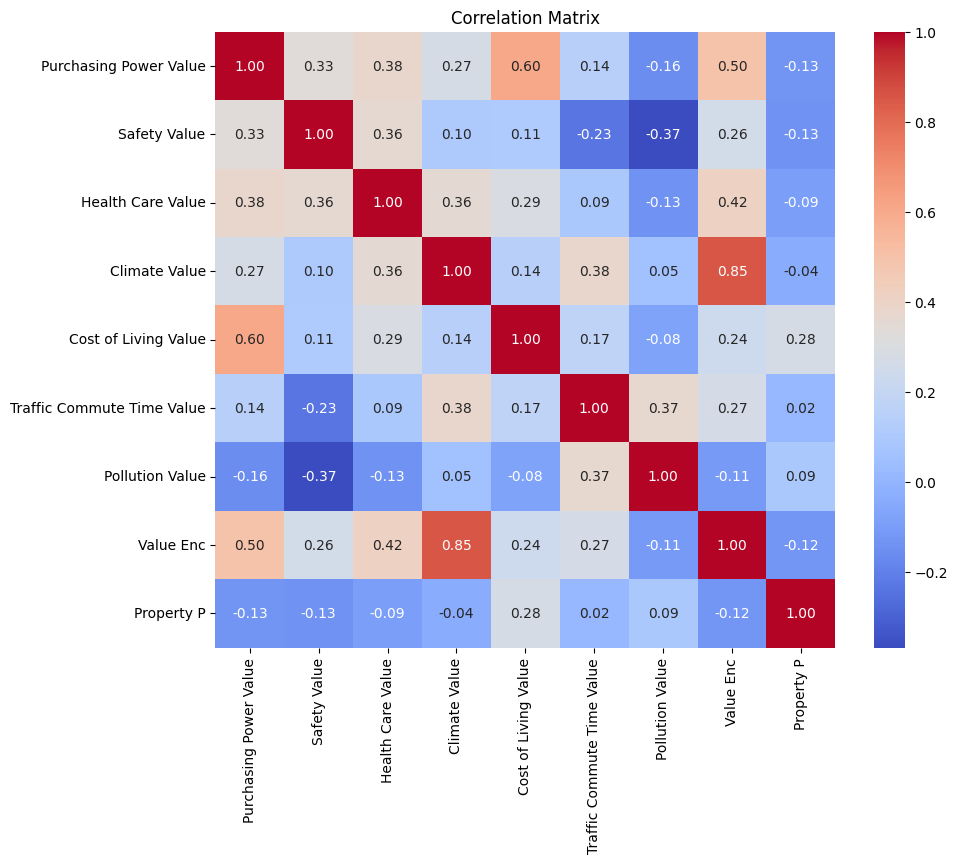

In [14]:
# Select float columns excluding 'Quality of Life Value'
float_columns = df.select_dtypes(include=['float64']).drop(columns=['Quality of Life Value'])

# Compute the correlation matrix
correlation_matrix = float_columns.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()